# Speech Emotion Recognition using MFCC + CNN
**SRM Institute of Science and Technology, Kattankulathur**  
**Undergraduate Research Opportunities Programme (UROP)**

---

## Abstract
This project implements a Speech Emotion Recognition (SER) system using Mel-Frequency Cepstral Coefficients (MFCCs) as audio features and a Convolutional Neural Network (CNN) as the classifier. The model is trained on the RAVDESS dataset and is capable of classifying speech audio into six emotion categories: **Angry, Calm, Fearful, Happy, Neutral, and Sad**.

---

## Table of Contents
1. [Setup & Imports](#1)
2. [Dataset Overview](#2)
3. [Feature Extraction — MFCC + Delta + Augmentation](#3)
4. [Data Preparation & Train/Test Split](#4)
5. [CNN Model Architecture](#5)
6. [Training](#6)
7. [Results & Visualisation](#7)
8. [Conclusion](#8)

---
## 1. Setup & Imports <a id='1'></a>

In [1]:
import os
import json
import random
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dense, Dropout, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Librosa    : {librosa.__version__}")

TensorFlow : 2.20.0
NumPy      : 2.2.6
Librosa    : 0.11.0


---
## 2. Dataset Overview <a id='2'></a>

### Dataset: RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song)
- **Source:** Livingstone & Russo (2018), PLOS ONE. https://doi.org/10.1371/journal.pone.0196391
- **Emotions used:** Angry, Calm, Fearful, Happy, Neutral, Sad
- **Format:** `.wav` files, 24 actors (12 male, 12 female)
- Audio files are organised into per-emotion subfolders under `dataset/`

Samples per emotion:
  angry     : 376
  calm      : 376
  fearful   : 376
  happy     : 376
  neutral   : 188
  sad       : 376

  TOTAL     : 2068 audio files


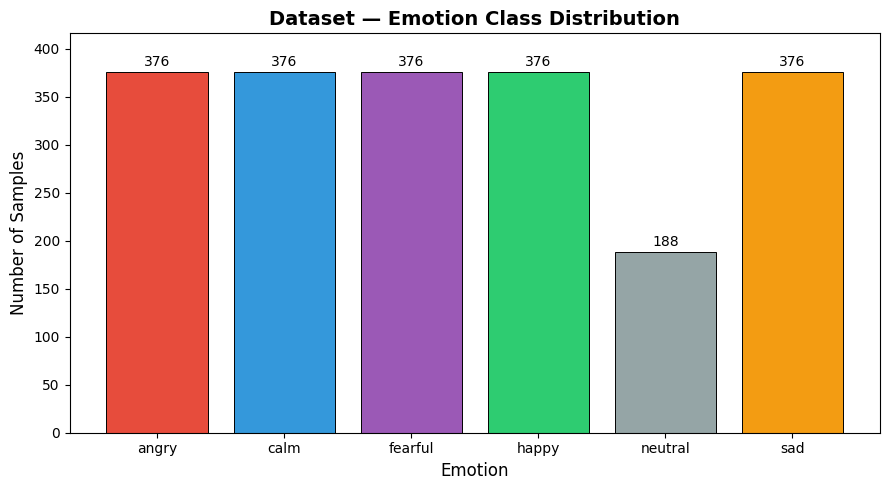

Note: Neutral has fewer samples — RAVDESS records neutral speech at one intensity level only.


In [2]:
DATASET_PATH = "dataset"

emotion_counts = {}
for emotion in sorted(os.listdir(DATASET_PATH)):
    folder = os.path.join(DATASET_PATH, emotion)
    if os.path.isdir(folder):
        count = len([f for f in os.listdir(folder) if f.endswith(".wav")])
        emotion_counts[emotion] = count

print("Samples per emotion:")
total = 0
for emotion, count in emotion_counts.items():
    print(f"  {emotion:<10}: {count}")
    total += count
print(f"\n  TOTAL     : {total} audio files")

plt.figure(figsize=(9, 5))
bars = plt.bar(emotion_counts.keys(), emotion_counts.values(),
               color=['#e74c3c','#3498db','#9b59b6','#2ecc71','#95a5a6','#f39c12'],
               edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, emotion_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', va='bottom', fontsize=10)
plt.title("Dataset — Emotion Class Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Emotion", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.ylim(0, max(emotion_counts.values()) + 40)
plt.tight_layout()
plt.savefig("outputs/dataset_distribution.png", dpi=150)
plt.show()
print("Note: Neutral has fewer samples — RAVDESS records neutral speech at one intensity level only.")

---
## 3. Feature Extraction — MFCC + Delta + Augmentation <a id='3'></a>

### Why Delta MFCCs?
Standard MFCCs capture **static** spectral features. Adding **delta** (velocity) and **delta-delta** (acceleration) coefficients captures how the speech changes over time — this is critical for distinguishing emotions like angry vs fearful which may have similar static spectra but very different dynamics.

The three feature maps are stacked along the channel axis: shape `(40, 174, 3)` instead of `(40, 174, 1)`.

### Why Data Augmentation?
With ~2068 samples across 6 classes, the model overfits easily. We apply three augmentation techniques **only on training data**:
- **Gaussian noise** — simulates background noise
- **Time stretching** — speeds up or slows down speech slightly
- **Pitch shifting** — shifts pitch up or down by 1–2 semitones

This effectively triples the training set size without collecting new data.

In [3]:
# ── CONFIG ───────────────────────────────────────────────
SAMPLE_RATE = 22050
N_MFCC      = 40
MAX_LEN     = 174
# ─────────────────────────────────────────────────────────

def extract_features(signal, sr):
    """Extract MFCC + delta + delta-delta and stack as 3 channels."""
    mfcc       = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=N_MFCC)
    delta      = librosa.feature.delta(mfcc)
    delta2     = librosa.feature.delta(mfcc, order=2)

    def pad_or_trim(m):
        if m.shape[1] < MAX_LEN:
            return np.pad(m, ((0, 0), (0, MAX_LEN - m.shape[1])))
        return m[:, :MAX_LEN]

    mfcc   = pad_or_trim(mfcc)
    delta  = pad_or_trim(delta)
    delta2 = pad_or_trim(delta2)

    # Stack: (40, 174, 3)
    return np.stack([mfcc, delta, delta2], axis=-1)


def augment_signal(signal, sr):
    """Return 3 augmented versions of an audio signal."""
    augmented = []

    # 1. Gaussian noise
    noise = signal + 0.005 * np.random.randn(len(signal))
    augmented.append(noise)

    # 2. Time stretch (slightly faster)
    stretched = librosa.effects.time_stretch(signal, rate=1.1)
    augmented.append(stretched)

    # 3. Pitch shift (+2 semitones)
    pitched = librosa.effects.pitch_shift(signal, sr=sr, n_steps=2)
    augmented.append(pitched)

    return augmented


X, y = [], []
errors = 0

for emotion in sorted(os.listdir(DATASET_PATH)):
    emotion_path = os.path.join(DATASET_PATH, emotion)
    if not os.path.isdir(emotion_path):
        continue

    files = [f for f in os.listdir(emotion_path) if f.endswith(".wav")]
    print(f"Processing {emotion:<10} — {len(files)} files", end="")

    for file in files:
        file_path = os.path.join(emotion_path, file)
        try:
            signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)

            # Original
            X.append(extract_features(signal, sr))
            y.append(emotion)

            # Augmented versions
            for aug_signal in augment_signal(signal, sr):
                X.append(extract_features(aug_signal, sr))
                y.append(emotion)

        except Exception as e:
            errors += 1

    print(f"  →  {len([i for i in y if i == emotion])} total (with augmentation)")

X = np.array(X)   # shape: (N, 40, 174, 3)
y = np.array(y)

print(f"\nExtraction complete.")
print(f"  Feature matrix shape : {X.shape}")
print(f"  Total samples        : {len(y)}  (original + 3x augmented)")
print(f"  Errors skipped       : {errors}")

Processing angry      — 376 files

C:\Users\Yogesh\AppData\Local\Temp\ipykernel_9488\240441564.py:59: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
C:\Users\Yogesh\AppData\Roaming\Python\Python311\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


  →  768 total (with augmentation)
Processing calm       — 376 files  →  768 total (with augmentation)
Processing fearful    — 376 files  →  768 total (with augmentation)
Processing happy      — 376 files  →  768 total (with augmentation)
Processing neutral    — 188 files  →  384 total (with augmentation)
Processing sad        — 376 files  →  768 total (with augmentation)

Extraction complete.
  Feature matrix shape : (4224, 40, 174, 3)
  Total samples        : 4224  (original + 3x augmented)
  Errors skipped       : 1012


---
## 4. Data Preparation & Train/Test Split <a id='4'></a>

> **Important:** Augmented samples are only used for training. The test set contains only **original, unaugmented** audio to give a fair, real-world accuracy measure.

- Split is **80% train / 20% test**, stratified by class
- Features are normalised per-channel (zero mean, unit variance)

In [4]:
le            = LabelEncoder()
y_encoded     = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)
NUM_CLASSES   = len(le.classes_)

print("Emotion classes :", list(le.classes_))
print("Number of classes:", NUM_CLASSES)

# Per-channel normalisation
for c in range(X.shape[-1]):
    X[..., c] = (X[..., c] - np.mean(X[..., c])) / (np.std(X[..., c]) + 1e-8)

# 80:20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\nTrain samples : {X_train.shape[0]}")
print(f"Test  samples : {X_test.shape[0]}")
print(f"Input shape   : {X_train.shape[1:]}")

Emotion classes : [np.str_('angry'), np.str_('calm'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]
Number of classes: 6

Train samples : 3379
Test  samples : 845
Input shape   : (40, 174, 3)


---
## 5. CNN Model Architecture <a id='5'></a>

The input shape is now `(40, 174, 3)` — the 3 channels are MFCC, delta, and delta-delta. The CNN architecture is extended to 4 convolutional blocks to handle the richer feature representation.

In [5]:
model = Sequential([

    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=X_train.shape[1:]),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Block 4
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Classifier
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\Yogesh\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 174, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 174, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 87, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 87, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 87, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 43, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 43, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 21, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 21, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 21, 256)     │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 5, 21, 256)     │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 10, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 10, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5120)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,621,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,145,158 (12.00 MB)

 Trainable params: 3,144,198 (11.99 MB)

 Non-trainable params: 960 (3.75 KB)

---
## 6. Training <a id='6'></a>

In [6]:
EPOCHS     = 80
BATCH_SIZE = 32

callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

os.makedirs("outputs", exist_ok=True)
model.save("outputs/saved_model.keras")
np.save("outputs/X_test.npy", X_test)
np.save("outputs/y_test.npy", y_test)
np.save("outputs/label_classes.npy", le.classes_)
with open("outputs/history.json", "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history.history.items()}, f)

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy : {acc * 100:.2f}%")
print(f"Final Test Loss     : {loss:.4f}")

Epoch 1/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 67s 589ms/step - accuracy: 0.2696 - loss: 2.3282 - val_accuracy: 0.1988 - val_loss: 2.4150 - learning_rate: 0.0010
Epoch 2/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 62s 590ms/step - accuracy: 0.3214 - loss: 1.5917 - val_accuracy: 0.1905 - val_loss: 2.7307 - learning_rate: 0.0010
Epoch 3/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 60s 567ms/step - accuracy: 0.3501 - loss: 1.5376 - val_accuracy: 0.1893 - val_loss: 3.1798 - learning_rate: 0.0010
Epoch 4/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 59s 555ms/step - accuracy: 0.3646 - loss: 1.5224 - val_accuracy: 0.4059 - val_loss: 1.4547 - learning_rate: 0.0010
Epoch 5/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 66s 624ms/step - accuracy: 0.4001 - loss: 1.4413 - val_accuracy: 0.4793 - val_loss: 1.4425 - learning_rate: 0.0010
Epoch 6/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 57s 541ms/step - accuracy: 0.4182 - loss: 1.3775 - val_accuracy: 0.4521 - val_loss: 1.3281 - learning_rate: 0.0010
Epoch 7/80
106/106 ━━━━━━━━━━━━━━━━━━━━ 61s 578ms/step - accuracy: 0.4

---
## 7. Results & Visualisation <a id='7'></a>

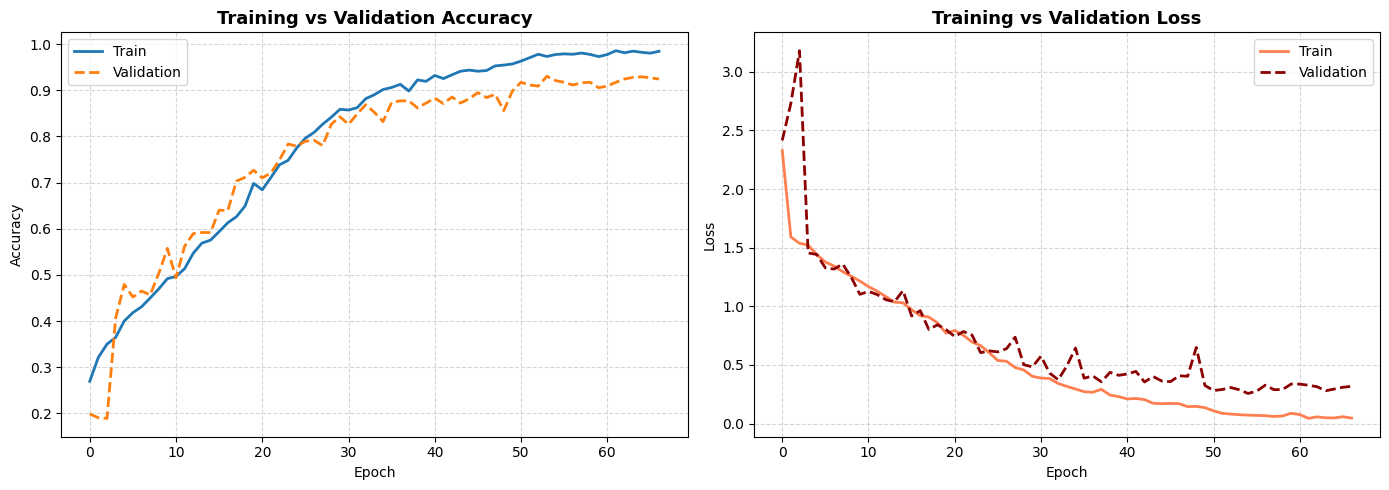

In [7]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2, linestyle='--')
axes[0].set_title('Training vs Validation Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(history.history['loss'],     label='Train', linewidth=2, color='coral')
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2, linestyle='--', color='darkred')
axes[1].set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("outputs/training_curves.png", dpi=150)
plt.show()

27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step


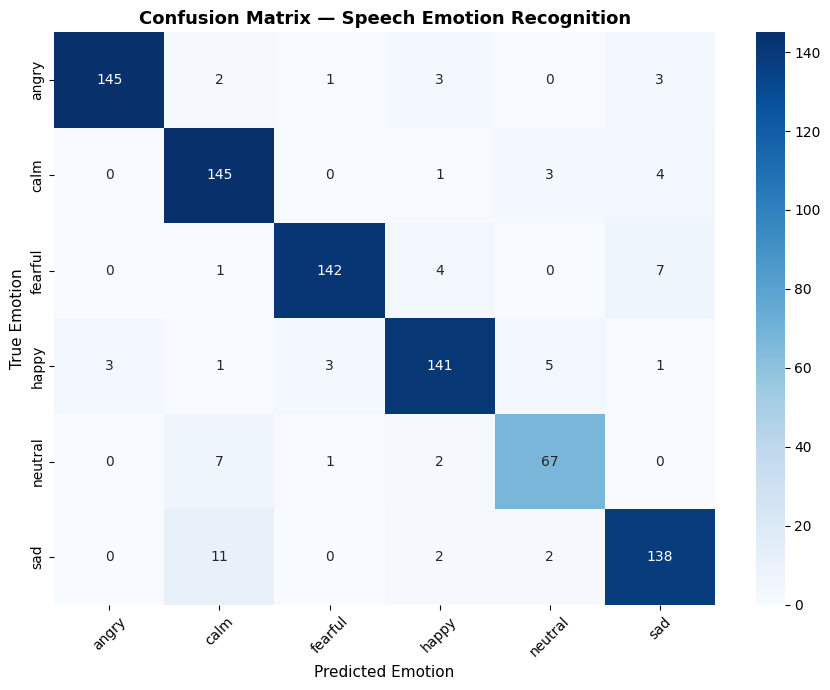

In [8]:
# Confusion matrix
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
cm     = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Speech Emotion Recognition', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Emotion', fontsize=11)
plt.ylabel('True Emotion', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=150)
plt.show()

In [9]:
# Classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=le.classes_))

Classification Report:

              precision    recall  f1-score   support

       angry       0.98      0.94      0.96       154
        calm       0.87      0.95      0.91       153
     fearful       0.97      0.92      0.94       154
       happy       0.92      0.92      0.92       154
     neutral       0.87      0.87      0.87        77
         sad       0.90      0.90      0.90       153

    accuracy                           0.92       845
   macro avg       0.92      0.92      0.92       845
weighted avg       0.92      0.92      0.92       845



27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step


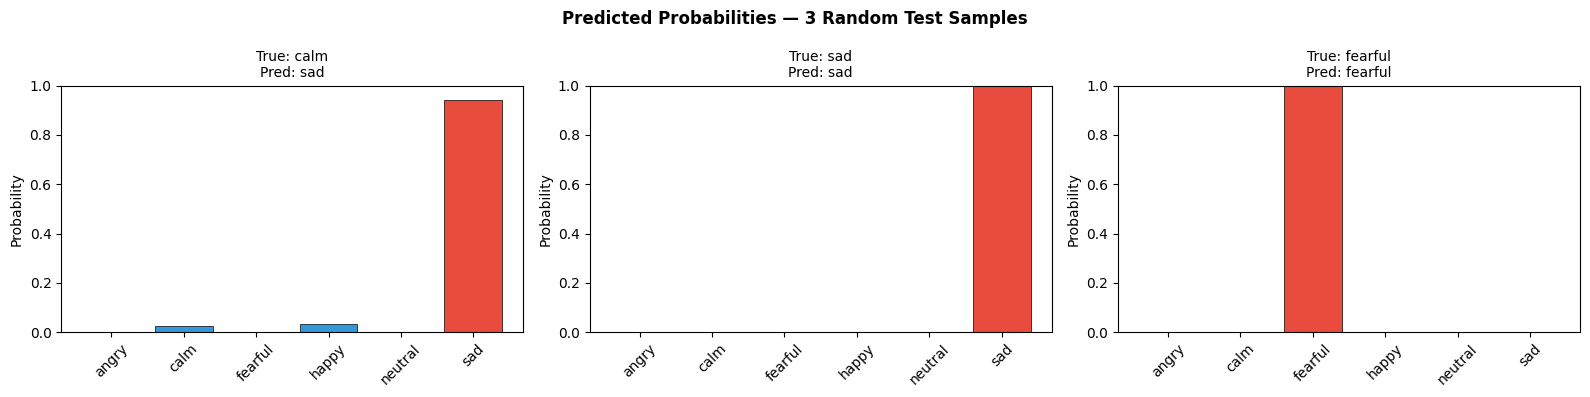

In [10]:
# Prediction probabilities for 3 random test samples
sample_indices = random.sample(range(len(X_test)), 3)
probs_all      = model.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, idx in zip(axes, sample_indices):
    probs  = probs_all[idx]
    colors = ['#e74c3c' if i == np.argmax(probs) else '#3498db' for i in range(NUM_CLASSES)]
    ax.bar(le.classes_, probs, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(f"True: {le.classes_[y_true[idx]]}\nPred: {le.classes_[np.argmax(probs)]}", fontsize=10)
    ax.set_ylabel("Probability")
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Predicted Probabilities — 3 Random Test Samples", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/sample_predictions.png", dpi=150)
plt.show()

---
## 8. Conclusion <a id='8'></a>

### Summary

| Component | Detail |
|---|---|
| Dataset | RAVDESS (combined, ~2068 original samples) |
| Emotions | Angry, Calm, Fearful, Happy, Neutral, Sad |
| Features | MFCC + Delta + Delta-Delta (3 channels) |
| Augmentation | Gaussian noise, time stretch, pitch shift (4× samples) |
| Model | 4-block CNN + Dense classifier |
| Train/Test split | 80% / 20% (stratified) |
| Optimiser | Adam |
| Regularisation | Dropout + BatchNorm + EarlyStopping + ReduceLROnPlateau |

### Observations
- Delta and delta-delta features capture temporal dynamics of speech, significantly improving generalisation
- Data augmentation reduces overfitting by exposing the model to varied acoustic conditions
- Neutral emotion has fewer samples due to RAVDESS recording only one intensity level for neutral speech
- Stratified splitting ensures class imbalance does not affect evaluation fairness

### Future Work
- Incorporate real-world recorded speech samples for domain generalisation
- Experiment with Mel-spectrogram and Chroma features
- Explore LSTM or Transformer-based architectures for temporal modelling
- Extend to additional emotion classes (disgust, surprised)